<a href="https://colab.research.google.com/github/Phionanamugga/Thesis/blob/feature1/early_exit_experimentsTFF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Early Exit Experiments with DistilBERT
This notebook demonstrates **dynamic efficiency methods** for transformers by adding *early exit classifiers* to DistilBERT.

**What this notebook includes:**
- Implementation of DistilBERT with early exit classifiers at intermediate layers.
- Evaluation on the **SST-2** dataset (GLUE benchmark).
- Experiments across **multiple confidence thresholds**.
- **Repeated runs (mean ± std)** to ensure robustness.
- Metrics: **Accuracy, Latency, Average Layers Used, Energy (CodeCarbon)**.
- **Plots with error bars** to show trade-offs.

---


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import DistilBertModel, DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import evaluate
import time
from tqdm.auto import tqdm
from codecarbon import OfflineEmissionsTracker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import wandb

In [3]:
# Explicitly set device to T4 GPU (Colab's default GPU)
DEVICE = torch.device("cuda:0")  # 'cuda:0' targets the first GPU (T4 in Colab)
print("Running on: T4 GPU")

Running on: T4 GPU


In [4]:
RESULTS_CSV = "/content/early_exit_results.csv"  # Adjusted for Colab

In [5]:

# Early Exit DistilBERT model definition
class DistilBertWithEarlyExit(nn.Module):
    def __init__(self, num_labels=2, confidence_threshold=0.9):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("distilbert-base-uncased")
        hidden_size = self.bert.config.hidden_size
        self.num_labels = num_labels
        self.confidence_threshold = confidence_threshold

        # Add classifiers after layer 2, 4, and 6
        self.classifiers = nn.ModuleDict({
            "layer2": nn.Linear(hidden_size, num_labels),
            "layer4": nn.Linear(hidden_size, num_labels),
            "layer6": nn.Linear(hidden_size, num_labels)
        })

    def forward(self, input_ids, attention_mask):
        outputs = self.bert.embeddings(input_ids)
        attn_mask = attention_mask

        for i, layer in enumerate(self.bert.transformer.layer, start=1):
            outputs = layer(outputs, attn_mask)[0]
            if i in [2, 4, 6]:
                logits = self.classifiers[f"layer{i}"](outputs[:, 0])
                probs = F.softmax(logits, dim=-1)
                conf, preds = torch.max(probs, dim=-1)

                if i < 6:
                    confident = conf >= self.confidence_threshold
                    if confident.sum().item() > 0:
                        return logits, i, preds, conf
                if i == 6:
                    return logits, i, preds, conf
        return logits, 6, preds, conf


In [6]:

# Load SST-2 dataset (GLUE)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
dataset = load_dataset("glue", "sst2")
eval_dataset = dataset["validation"].map(
    lambda b: tokenizer(b["sentence"], truncation=True, padding="max_length", max_length=128),
    batched=True
)
eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
eval_loader = torch.utils.data.DataLoader(eval_dataset, batch_size=16)
print("Validation samples:", len(eval_dataset))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Validation samples: 872


In [11]:
# Load SST-2 dataset (GLUE)
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
dataset = load_dataset("glue", "sst2")
train_dataset = dataset["train"].map(
    lambda b: tokenizer(b["sentence"], truncation=True, padding="max_length", max_length=128),
    batched=True
)
eval_dataset = dataset["validation"].map(
    lambda b: tokenizer(b["sentence"], truncation=True, padding="max_length", max_length=128),
    batched=True
)
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
eval_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
eval_loader = torch.utils.data.DataLoader(eval_dataset, batch_size=16)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(eval_dataset))

Train samples: 67349
Validation samples: 872


In [ ]:
def fine_tune_distilbert():
    print("Fine-tuning DistilBERT...")
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
    training_args = TrainingArguments(
        output_dir="./distilbert_fine_tuned",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy="epoch",
        learning_rate=2e-5,
        seed=42,
        report_to="wandb"  # Log to WandB
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset
    )

    trainer.train()
    model.save_pretrained("./distilbert_fine_tuned")
    return model

# Fine-tune the base model
fine_tuned_model = fine_tune_distilbert()

Fine-tuning DistilBERT...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: phionanamugga23 (phionanamugga23-gisma-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,0.186000,0.290868
2,0.138700,0.396091


In [24]:
# Early Exit DistilBERT model definition using fine-tuned base
class DistilBertWithEarlyExit(nn.Module):
    def __init__(self, num_labels=2, confidence_threshold=0.9):
        super().__init__()
        self.bert = DistilBertModel.from_pretrained("./distilbert_fine_tuned")  # Use fine-tuned base
        hidden_size = self.bert.config.hidden_size
        self.num_labels = num_labels
        self.confidence_threshold = confidence_threshold
        self.num_heads = self.bert.config.num_attention_heads  # Get number of heads (12 for DistilBert)

        # Add classifiers after layer 2, 4, and 6
        self.classifiers = nn.ModuleDict({
            "layer2": nn.Linear(hidden_size, num_labels),
            "layer4": nn.Linear(hidden_size, num_labels),
            "layer6": nn.Linear(hidden_size, num_labels)
        })

    def forward(self, input_ids, attention_mask):
        # Convert attention_mask to boolean and expand for multi-head attention
        attn_mask = attention_mask.bool().unsqueeze(1).unsqueeze(2).expand(-1, self.num_heads, -1, -1)
        outputs = self.bert.embeddings(input_ids)

        for i, layer in enumerate(self.bert.transformer.layer, start=1):
            outputs = layer(outputs, attn_mask)[0]
            if i in [2, 4, 6]:
                logits = self.classifiers[f"layer{i}"](outputs[:, 0])
                probs = F.softmax(logits, dim=-1)
                conf, preds = torch.max(probs, dim=-1)

                if i < 6:
                    confident = conf >= self.confidence_threshold
                    if confident.sum().item() > 0:
                        return logits, i, preds, conf
                if i == 6:
                    return logits, i, preds, conf
        return logits, 6, preds, conf

In [25]:
def evaluate_with_threshold(threshold):
    model = DistilBertWithEarlyExit(num_labels=2, confidence_threshold=threshold).to(DEVICE)
    model.eval()

    total_correct, total_samples = 0, 0
    layer_usage, latencies = [], []

    tracker = OfflineEmissionsTracker(country_iso_code="DEU", save_to_file=False, log_level='debug')
    tracker.start()

    with torch.no_grad():
        for batch in eval_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            t0 = time.perf_counter()
            logits, exit_layer, preds, conf = model(input_ids, attn)
            t1 = time.perf_counter()

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            layer_usage.append(exit_layer)
            latencies.append((t1 - t0) / labels.size(0))

    emissions = tracker.stop()

    accuracy = total_correct / total_samples
    avg_latency_ms = np.mean(latencies) * 1000
    avg_layers_used = np.mean(layer_usage)

In [26]:
def evaluate_with_threshold(threshold):
    model = DistilBertWithEarlyExit(num_labels=2, confidence_threshold=threshold).to(DEVICE)
    model.eval()

    total_correct, total_samples = 0, 0
    layer_usage, latencies = [], []

    tracker = OfflineEmissionsTracker(country_iso_code="DEU", save_to_file=False, log_level='debug')
    tracker.start()

    with torch.no_grad():
        for batch in eval_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn = batch["attention_mask"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            t0 = time.perf_counter()
            logits, exit_layer, preds, conf = model(input_ids, attn)
            t1 = time.perf_counter()

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            layer_usage.append(exit_layer)
            latencies.append((t1 - t0) / labels.size(0))

    emissions = tracker.stop()

    accuracy = total_correct / total_samples
    avg_latency_ms = np.mean(latencies) * 1000
    avg_layers_used = np.mean(layer_usage)

    # Extract energy/emissions (kg CO₂eq if available)
    energy_val = None
    if isinstance(emissions, dict):
        for k in ["emissions_kg", "emissions", "energy_consumed"]:
            if k in emissions:
                energy_val = emissions[k]
                break

    # Log to WandB
    wandb.init(project="early_exit_experiments", name=f"threshold_{threshold}")
    wandb.log({
        "accuracy": accuracy,
        "avg_latency_ms": avg_latency_ms,
        "avg_layers_used": avg_layers_used,
        "energy_consumed": energy_val
    })
    wandb.finish()

    return accuracy, avg_latency_ms, avg_layers_used, energy_val

In [27]:
def run_repeated(thresholds=[0.7, 0.8, 0.9, 0.95], repeats=3, results_csv=RESULTS_CSV):
    results = []
    for th in thresholds:
        accs, lats, layers, energies = [], [], [], []
        for r in range(repeats):
            print(f"Threshold {th}, run {r+1}/{repeats}")
            acc, lat, lay, en = evaluate_with_threshold(th)
            accs.append(acc)
            lats.append(lat)
            layers.append(lay)
            energies.append(en if en is not None else np.nan)

        res = {
            "threshold": th,
            "acc_mean": np.mean(accs), "acc_std": np.std(accs),
            "lat_mean": np.mean(lats), "lat_std": np.std(lats),
            "layers_mean": np.mean(layers), "layers_std": np.std(layers),
            "energy_mean": np.nanmean(energies), "energy_std": np.nanstd(energies)
        }
        results.append(res)

    df = pd.DataFrame(results)
    df.to_csv(results_csv, index=False)
    print("Results saved to", results_csv)
    return df

df = run_repeated(thresholds=[0.7, 0.8, 0.9, 0.95], repeats=3)
df

Threshold 0.7, run 1/3


[codecarbon DEBUG @ 13:16:06] RAM power estimation: 10.00W for 12.67GB
[codecarbon INFO @ 13:16:06] Energy consumed for RAM : 0.003081 kWh. RAM Power : 10.0 W
[codecarbon DEBUG @ 13:16:06] Done measure for RAM - measurement time: 0.0056 s - last call 15.00 s
[codecarbon INFO @ 13:16:06] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 13:16:06] Energy consumed for All CPU : 0.013098 kWh
[codecarbon DEBUG @ 13:16:06] Done measure for CPU - measurement time: 0.0021 s - last call 15.01 s
[codecarbon INFO @ 13:16:06] Energy consumed for all GPUs : 0.009964 kWh. Total GPU Power : 32.47823565235097 W
[codecarbon DEBUG @ 13:16:06] Done measure for GPU - measurement time: 0.0058 s - last call 15.01 s
[codecarbon INFO @ 13:16:06] 0.026144 kWh of electricity used since the beginning.
[codecarbon DEBUG @ 13:16:06] last_duration=14.995424122999793
------------------------
[codecarbon INFO @ 13:16:06] offline tracker init
[codecarbon WARNING @ 13:16:06] 

eval/loss,▁▇█
eval/runtime,█▁▇
eval/samples_per_second,▁█▂
eval/steps_per_second,▁█▂
train/epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇████
train/global_step,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇████
train/grad_norm,▅▅▃▃▃▇▃▄▆▁▂▄▄▁█▁▁▁▆▅▄▃▁▁▁
train/learning_rate,██▇▇▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▂▂▂▂▁▁
train/loss,█▆▅▅▄▄▄▄▃▂▂▂▂▂▂▃▂▁▁▁▁▁▁▁▁
eval/loss,0.42406
eval/runtime,3.1401


[codecarbon DEBUG @ 13:16:14] RAM power estimation: 10.00W for 12.67GB
[codecarbon INFO @ 13:16:14] Energy consumed for RAM : 0.000916 kWh. RAM Power : 10.0 W
[codecarbon DEBUG @ 13:16:14] Done measure for RAM - measurement time: 0.0042 s - last call 14.99 s
[codecarbon INFO @ 13:16:14] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 13:16:14] Energy consumed for All CPU : 0.003894 kWh
[codecarbon DEBUG @ 13:16:14] Done measure for CPU - measurement time: 0.0016 s - last call 14.99 s
[codecarbon INFO @ 13:16:14] Energy consumed for all GPUs : 0.003005 kWh. Total GPU Power : 41.81712749095408 W
[codecarbon DEBUG @ 13:16:14] Done measure for GPU - measurement time: 0.0074 s - last call 14.99 s
[codecarbon INFO @ 13:16:14] 0.007814 kWh of electricity used since the beginning.
[codecarbon DEBUG @ 13:16:14] last_duration=14.986288681999213
------------------------


accuracy,▁
avg_latency_ms,▁
avg_layers_used,▁
accuracy,0.38417
avg_latency_ms,2.80249
avg_layers_used,6


...

[codecarbon DEBUG @ 13:17:19] RAM power estimation: 10.00W for 12.67GB
[codecarbon INFO @ 13:17:19] Energy consumed for RAM : 0.001624 kWh. RAM Power : 10.0 W
[codecarbon DEBUG @ 13:17:19] Done measure for RAM - measurement time: 0.0020 s - last call 14.99 s
[codecarbon INFO @ 13:17:19] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 13:17:19] Energy consumed for All CPU : 0.006903 kWh
[codecarbon DEBUG @ 13:17:19] Done measure for CPU - measurement time: 0.0027 s - last call 14.99 s
[codecarbon INFO @ 13:17:19] Energy consumed for all GPUs : 0.005637 kWh. Total GPU Power : 49.58972587359254 W
[codecarbon DEBUG @ 13:17:19] Done measure for GPU - measurement time: 0.0029 s - last call 15.00 s
[codecarbon INFO @ 13:17:19] 0.014164 kWh of electricity used since the beginning.
[codecarbon DEBUG @ 13:17:19] last_duration=14.991238858999168
------------------------
[codecarbon WARNING @ 13:17:19] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00

accuracy,▁
avg_latency_ms,▁
avg_layers_used,▁
accuracy,0.51376
avg_latency_ms,2.40899
avg_layers_used,6


Results saved to /content/early_exit_results.csv


/tmp/ipython-input-3064215301.py:18: RuntimeWarning: Mean of empty slice
  "energy_mean": np.nanmean(energies), "energy_std": np.nanstd(energies)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,threshold,acc_mean,acc_std,lat_mean,lat_std,layers_mean,layers_std,energy_mean,energy_std
0,0.70,0.347477,0.134551,2.151631,0.704244,4.666667,1.885618,NaN,NaN
1,0.80,0.471330,0.063257,2.477716,0.026102,6.000000,0.000000,NaN,NaN
2,0.90,0.545107,0.232217,2.404974,0.022325,6.000000,0.000000,NaN,NaN
3,0.95,0.480505,0.108846,2.378414,0.021814,6.000000,0.000000,NaN,NaN


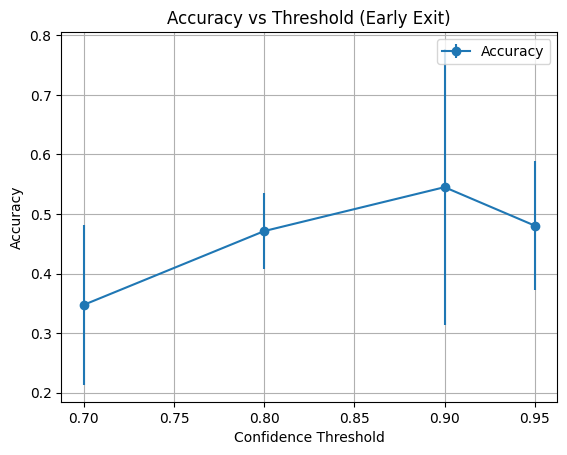

[codecarbon DEBUG @ 13:19:20] RAM power estimation: 10.00W for 12.67GB
[codecarbon INFO @ 13:19:20] Energy consumed for RAM : 0.002498 kWh. RAM Power : 10.0 W
[codecarbon DEBUG @ 13:19:20] Done measure for RAM - measurement time: 0.0054 s - last call 14.99 s
[codecarbon INFO @ 13:19:20] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 13:19:20] Energy consumed for All CPU : 0.010619 kWh
[codecarbon DEBUG @ 13:19:20] Done measure for CPU - measurement time: 0.0018 s - last call 15.00 s
[codecarbon INFO @ 13:19:20] Energy consumed for all GPUs : 0.008483 kWh. Total GPU Power : 31.839438962790865 W
[codecarbon DEBUG @ 13:19:20] Done measure for GPU - measurement time: 0.0032 s - last call 15.01 s
[codecarbon INFO @ 13:19:20] 0.021600 kWh of electricity used since the beginning.
[codecarbon DEBUG @ 13:19:20] last_duration=14.990017465000165
------------------------


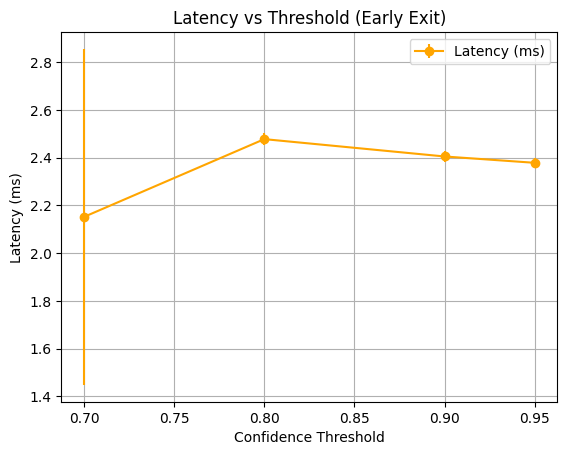

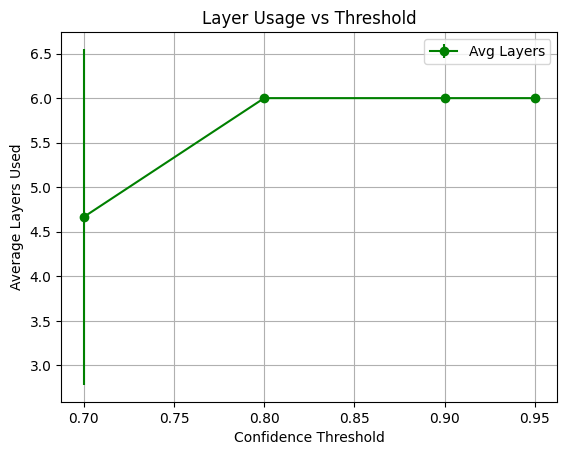

In [29]:
# Plot results with error bars
def plot_results(df, output_prefix="/content/early_exit_plot"):
    plt.errorbar(df["threshold"], df["acc_mean"], yerr=df["acc_std"], marker="o", label="Accuracy")
    plt.xlabel("Confidence Threshold"); plt.ylabel("Accuracy")
    plt.title("Accuracy vs Threshold (Early Exit)"); plt.grid(True); plt.legend()
    plt.savefig(f"{output_prefix}_accuracy.png"); plt.show()

    plt.errorbar(df["threshold"], df["lat_mean"], yerr=df["lat_std"], marker="o", color="orange", label="Latency (ms)")
    plt.xlabel("Confidence Threshold"); plt.ylabel("Latency (ms)")
    plt.title("Latency vs Threshold (Early Exit)"); plt.grid(True); plt.legend()
    plt.savefig(f"{output_prefix}_latency.png"); plt.show()

    plt.errorbar(df["threshold"], df["layers_mean"], yerr=df["layers_std"], marker="o", color="green", label="Avg Layers")
    plt.xlabel("Confidence Threshold"); plt.ylabel("Average Layers Used")
    plt.title("Layer Usage vs Threshold"); plt.grid(True); plt.legend()
    plt.savefig(f"{output_prefix}_layers.png"); plt.show()


plot_results(df)

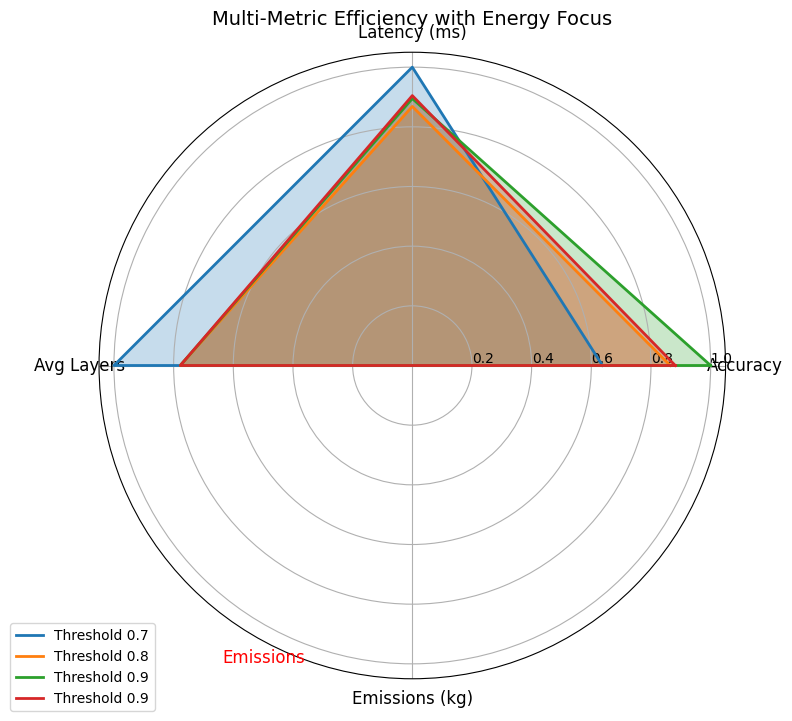

In [33]:
def radar_chart(df, output_prefix="/content/early_exit_plot"):
    # Define metrics
    metrics = ["acc_mean", "lat_mean", "layers_mean", "energy_mean"]
    labels = ["Accuracy", "Latency (ms)", "Avg Layers", "Emissions (kg)"]

    # Normalize metrics (higher is better, invert latency and energy)
    df_norm = df.copy()
    for m in metrics:
        if m == "acc_mean":
            df_norm[m] = df_norm[m] / df_norm[m].max()
        else:
            df_norm[m] = 1 / (df_norm[m] / df_norm[m].min()) if df_norm[m].min() > 0 else 0

    # Radar chart setup
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    # Plot for each threshold
    for idx, row in df_norm.iterrows():
        values = [row[m] for m in metrics]
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=f"Threshold {row['threshold']:.1f}")
        ax.fill(angles, values, alpha=0.25)

    # Customize the plot with emphasis on energy
    plt.xticks(angles[:-1], labels, size=12)
    plt.title("Multi-Metric Efficiency with Energy Focus", size=14, pad=20)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], size=10)
    plt.legend(loc="upper right", bbox_to_anchor=(0.1, 0.1))

    # Highlight energy usage
    ax.text(angles[3] * 0.9, 1.1, "Emissions", ha="center", va="center", color="red", fontsize=12)

    plt.tight_layout()
    plt.savefig(f"{output_prefix}_radar.png", dpi=300, bbox_inches="tight")
    plt.show()

# Generate radar chart
radar_chart(df)


## ✅ Summary
This notebook shows how **Early Exit Mechanisms** can trade off accuracy and efficiency:  
- Lower thresholds → higher accuracy but more layers, higher latency & energy.  
- Higher thresholds → more early exits, lower latency & energy, possible accuracy drop.  

These plots can be directly included in your thesis to illustrate **dynamic methods** for efficient transformers.
